In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

np.random.seed(42)
tf.random.set_seed(42)
print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


In [2]:
clases = ['Camiseta','Pantalón','Suéter','Vestido','Abrigo',
          'Sandalia','Camisa','Zapatilla','Bolso','Botín']

(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalizar y agregar canal
X_train = (X_train / 255.0)[..., np.newaxis].astype('float32')
X_test  = (X_test  / 255.0)[..., np.newaxis].astype('float32')

print('Train:', X_train.shape, '| Test:', X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28, 1) | Test: (10000, 28, 28, 1)


In [3]:
def crear_pares(X, y, n_pares=5000):
    """Genera pares positivos y negativos balanceados."""
    pares_A, pares_B, etiquetas = [], [], []
    clases_unicas = np.unique(y)
    # Índices por clase
    idx_por_clase = {c: np.where(y == c)[0] for c in clases_unicas}

    for _ in range(n_pares // 2):
        # Par POSITIVO: misma clase
        clase = np.random.choice(clases_unicas)
        i1, i2 = np.random.choice(idx_por_clase[clase], 2, replace=False)
        pares_A.append(X[i1]); pares_B.append(X[i2]); etiquetas.append(1)

        # Par NEGATIVO: clases distintas
        c1, c2 = np.random.choice(clases_unicas, 2, replace=False)
        i1 = np.random.choice(idx_por_clase[c1])
        i2 = np.random.choice(idx_por_clase[c2])
        pares_A.append(X[i1]); pares_B.append(X[i2]); etiquetas.append(0)

    return (np.array(pares_A), np.array(pares_B), np.array(etiquetas, dtype='float32'))

A_train, B_train, labels_train = crear_pares(X_train, y_train, n_pares=10000)
A_test,  B_test,  labels_test  = crear_pares(X_test,  y_test,  n_pares=2000)

print(f'Pares entrenamiento: {len(labels_train)} | Pares prueba: {len(labels_test)}')
print(f'Positivos: {labels_train.sum():.0f} | Negativos: {(1-labels_train).sum():.0f}')

Pares entrenamiento: 10000 | Pares prueba: 2000
Positivos: 5000 | Negativos: 5000


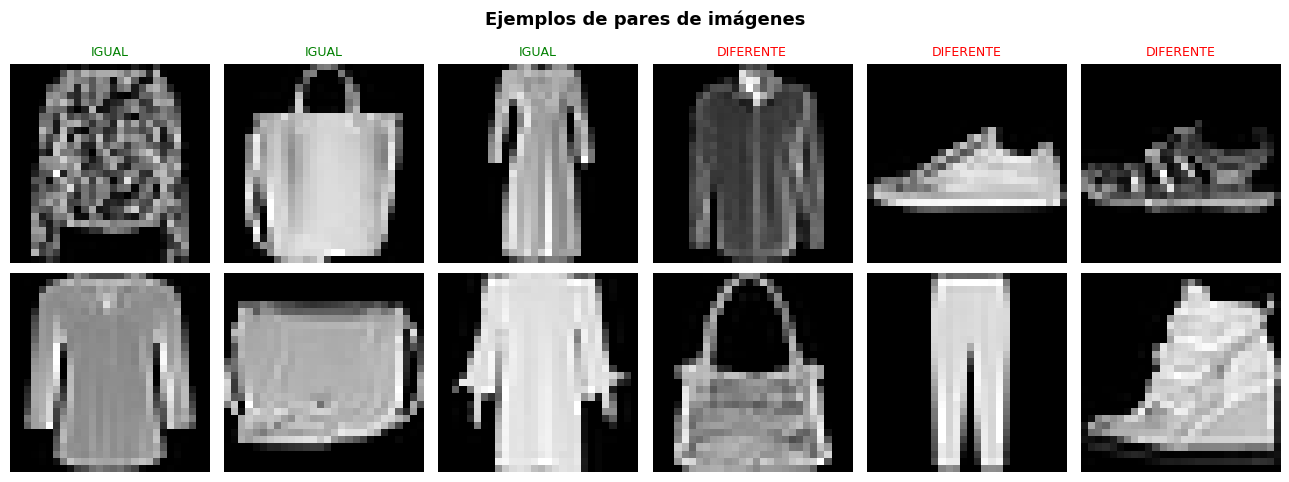

In [12]:
fig, axes = plt.subplots(2, 6, figsize=(13, 5))
fig.suptitle('Ejemplos de pares de imágenes', fontsize=13, fontweight='bold')

# 3 pares positivos + 3 negativos
pos_idx = np.where(labels_train == 1)[0][:3]
neg_idx = np.where(labels_train == 0)[0][:3]

for col, idx in enumerate(pos_idx):
    axes[0, col].imshow(A_train[idx].squeeze(), cmap='gray')
    axes[0, col].set_title('IGUAL', color='green', fontsize=9)
    axes[0, col].axis('off')
    axes[1, col].imshow(B_train[idx].squeeze(), cmap='gray')
    axes[1, col].axis('off')

for col, idx in enumerate(neg_idx):
    axes[0, col+3].imshow(A_train[idx].squeeze(), cmap='gray')
    axes[0, col+3].set_title('DIFERENTE', color='red', fontsize=9)
    axes[0, col+3].axis('off')
    axes[1, col+3].imshow(B_train[idx].squeeze(), cmap='gray')
    axes[1, col+3].axis('off')

plt.tight_layout()
plt.show()

In [5]:
def red_base():
    """CNN que convierte una imagen en un vector de 64 dimensiones."""
    entrada = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, (3,3), activation='relu')(entrada)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, (3,3), activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    # L2 normalización: los vectores quedan sobre una esfera unitaria
    salida = layers.Lambda(lambda v: tf.math.l2_normalize(v, axis=1))(x)
    return Model(entrada, salida, name='red_base')

# La MISMA red se aplica a las dos imágenes
encoder = red_base()
encoder.summary()

Model: "red_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 64)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,280 (473.75 KB)

 Trainable params: 121,280 (473.75 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Dos entradas: imagen A e imagen B
input_A = keras.Input(shape=(28, 28, 1), name='imagen_A')
input_B = keras.Input(shape=(28, 28, 1), name='imagen_B')

# Misma red (mismos pesos) para las dos imágenes
vector_A = encoder(input_A)
vector_B = encoder(input_B)

# Calcular distancia euclidiana entre los dos vectores
distancia = layers.Lambda(
    lambda x: tf.sqrt(tf.reduce_sum(tf.square(x[0] - x[1]), axis=1, keepdims=True)),
    name='distancia_euclidiana'
)([vector_A, vector_B])

# Convertir distancia a probabilidad de similitud (0 a 1)
salida = layers.Dense(1, activation='sigmoid', name='similitud')(distancia)

modelo_siames = Model(inputs=[input_A, input_B], outputs=salida, name='red_siamesa')
modelo_siames.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

modelo_siames.summary()

Model: "red_siamesa"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ imagen_A            │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ imagen_B            │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ red_base            │ (None, 64)        │    121,280 │ imagen_A[0][0],   │
│ (Functional)        │                   │            │ imagen_B[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ distancia_euclidia… │ (None, 1)         │          0 │ red_base[0][0],   │
│ (Lambda)            │                   │            │ red_base[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ similitud (Dense)   │ (None, 1)         │          2 │ distancia_euclid… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 121,282 (473.76 KB)

 Trainable params: 121,282 (473.76 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
historial = modelo_siames.fit(
    [A_train, B_train], labels_train,
    epochs=8,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

loss, acc = modelo_siames.evaluate([A_test, B_test], labels_test, verbose=0)
print(f'\nAccuracy en test: {acc:.4f} | Loss: {loss:.4f}')

Epoch 1/8
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 108ms/step - accuracy: 0.4901 - loss: 0.6929 - val_accuracy: 0.5010 - val_loss: 0.6943
Epoch 2/8
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 104ms/step - accuracy: 0.4981 - loss: 0.6925 - val_accuracy: 0.5000 - val_loss: 0.6969
Epoch 3/8
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 100ms/step - accuracy: 0.5086 - loss: 0.6914 - val_accuracy: 0.5000 - val_loss: 0.7002
Epoch 4/8
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.5216 - loss: 0.6892 - val_accuracy: 0.5000 - val_loss: 0.7049
Epoch 5/8
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - accuracy: 0.5328 - loss: 0.6852 - val_accuracy: 0.4940 - val_loss: 0.7078
Epoch 6/8
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - accuracy: 0.5544 - loss: 0.6801 - val_accuracy: 0.4790 - val_loss: 0.7081
Epoch 7/8
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - accuracy: 0.5777 - loss: 0.6740 - val_accuracy: 0.4870 - val_loss: 0.7048
Epoch 8/8
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - accuracy: 0.6023 - loss: 0.6676 - val_

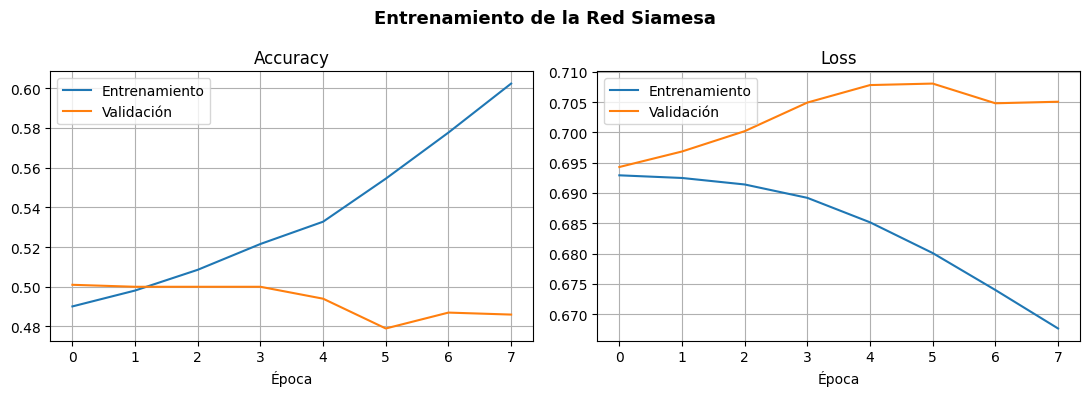

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Entrenamiento de la Red Siamesa', fontsize=13, fontweight='bold')

ax1.plot(historial.history['accuracy'],     label='Entrenamiento')
ax1.plot(historial.history['val_accuracy'], label='Validación')
ax1.set_title('Accuracy'); ax1.set_xlabel('Época')
ax1.legend(); ax1.grid(True)

ax2.plot(historial.history['loss'],     label='Entrenamiento')
ax2.plot(historial.history['val_loss'], label='Validación')
ax2.set_title('Loss'); ax2.set_xlabel('Época')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_12857/682518859.py:15: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


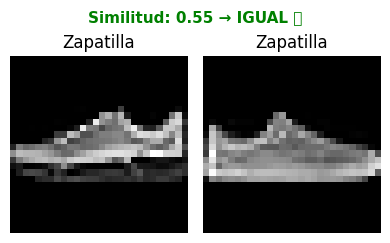

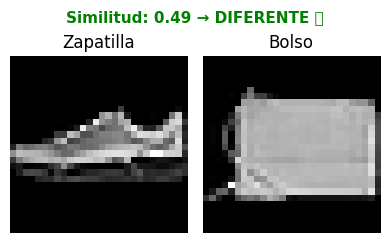

/tmp/ipykernel_12857/682518859.py:15: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


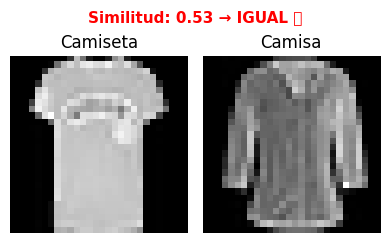

In [18]:
def probar_par(imgA, imgB, etiqueta_real, clase_A, clase_B):
    """Muestra un par y la predicción del modelo."""
    a = imgA[np.newaxis, ...]
    b = imgB[np.newaxis, ...]
    similitud = modelo_siames.predict([a, b], verbose=0)[0][0]
    prediccion = 'IGUAL' if similitud > 0.5 else 'DIFERENTE'
    correcto   = prediccion == ('IGUAL' if etiqueta_real == 1 else 'DIFERENTE')

    fig, axes = plt.subplots(1, 2, figsize=(4, 2.5))
    axes[0].imshow(imgA.squeeze(), cmap='gray'); axes[0].set_title(clase_A); axes[0].axis('off')
    axes[1].imshow(imgB.squeeze(), cmap='gray'); axes[1].set_title(clase_B); axes[1].axis('off')
    color = 'green' if correcto else 'red'
    fig.suptitle(f'Similitud: {similitud:.2f} → {prediccion} {"✅" if correcto else "❌"}',
                 fontsize=11, color=color, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Test 1: Par positivo — dos zapatillas
idx_zap = np.where(y_test == 7)[0]
probar_par(X_test[idx_zap[0]], X_test[idx_zap[1]], 1, 'Zapatilla', 'Zapatilla')

# Test 2: Par negativo — zapatilla vs bolso
idx_bol = np.where(y_test == 8)[0]
probar_par(X_test[idx_zap[0]], X_test[idx_bol[0]], 0, 'Zapatilla', 'Bolso')

# Test 3: Par difícil — camiseta vs camisa (visualmente parecidos)
idx_cam  = np.where(y_test == 0)[0]
idx_cami = np.where(y_test == 6)[0]
probar_par(X_test[idx_cam[0]], X_test[idx_cami[0]], 0, 'Camiseta', 'Camisa')

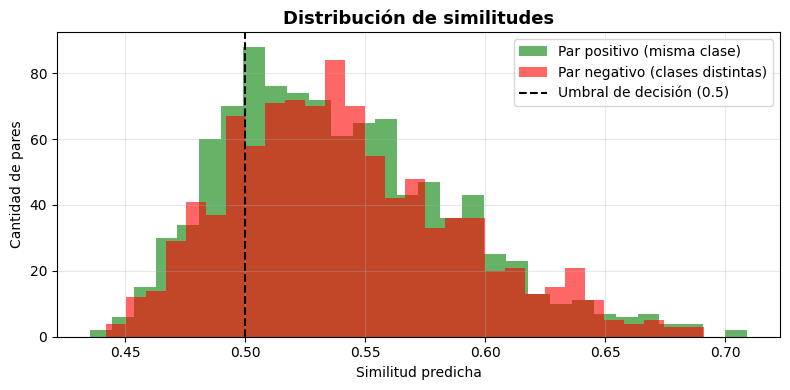

Similitud media — pares iguales:     0.539
Similitud media — pares diferentes:  0.541


In [11]:
# Predecir similitud sobre los pares de prueba
preds = modelo_siames.predict([A_test, B_test], batch_size=128, verbose=0).flatten()

sim_pos = preds[labels_test == 1]  # Pares de la misma clase
sim_neg = preds[labels_test == 0]  # Pares de distinta clase

plt.figure(figsize=(8, 4))
plt.hist(sim_pos, bins=30, alpha=0.6, color='green', label='Par positivo (misma clase)')
plt.hist(sim_neg, bins=30, alpha=0.6, color='red',   label='Par negativo (clases distintas)')
plt.axvline(0.5, color='black', linestyle='--', label='Umbral de decisión (0.5)')
plt.xlabel('Similitud predicha')
plt.ylabel('Cantidad de pares')
plt.title('Distribución de similitudes', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Similitud media — pares iguales:     {sim_pos.mean():.3f}')
print(f'Similitud media — pares diferentes:  {sim_neg.mean():.3f}')

Pares positivos (misma clase):
El modelo asigna una similitud alta (cercana a 1) cuando las dos imágenes pertenecen a la misma categoría. Esto indica que los vectores aprendidos en el espacio latente son cercanos entre sí para objetos del mismo tipo.

Pares negativos (clases distintas):
La similitud es baja (cercana a 0) para pares de clases diferentes, lo que indica que el modelo aprendió a separar categorías en el espacio de representación.

Pares difíciles (ej: Camiseta vs Camisa):
Visualmente son parecidos y el modelo puede confundirlos. Esto es esperado y refleja la dificultad inherente del problema — también ocurre en reconocimiento facial con gemelos.